# Проект спринта 11: Модель для прогнозирования оттока клиентов для сервиса доставки кофе

**Выполнил:** Артем Буров  
**Группа:** DS12  
**Дата:** 30 мая 2026  
**Ссылка на GitHub:** https://github.com/TemaQDX/project_happy_coffe_beans

## Описание задачи
Компания **Happy Beans Coffee** ранее она занималась производством кофемашин и продажей элитного кофе, а недавно запустила собственный сервис по его доставке, и ей нужен совет по поводу удержания покупателей.
На рынке доставки кофе высокая конкуренция, поэтому привлечение нового клиента обходится в 5–7 раз дороже, чем удержание существующего. В последние месяцы Happy Beans Coffee столкнулись с проблемой: каждый месяц сервис теряет 10% клиентской базы, что напрямую снижает ежемесячную выручку. Из-за этого также неэффективно расходуется маркетинговый бюджет: он «работает вхолостую», не обеспечивая прироста клиентской базы.  

Необходимо построить **модель бинарной классификации на основе Логистической регрессии** `LogisticRegression`, которая спрогнозирует вероятность оттока каждого клиента в следующем месяце.  
В качестве основной метрики оценки качества модели будет использованы **Precision-Recall AUC (PR AUC)**. Она фокусируется на корректном предсказании меньшего по объёму, но ключевого для задачи класса — уходящих клиентов.

## Описание данных

Для решения задачи аналитики компании Happy Beans Coffee подготовили датасет `coffee_churn_dataset`, доступный для загрузки по ссылке https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv. Данные были собраны из внутренних систем компании: транзакционной базы данных, логов мобильного приложения и результатов опросов.  

Что важно знать про данные:  
- Период агрегации. Признаки агрегированы за последние 4 недели.  
- Формат данных. Они представлены в виде готовой аналитической витрины. Это означает, что для каждого клиента уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки.  
- Структура. Каждая строка — это один уникальный клиент. Все признаки уже вычислены и представлены в виде числовых и категориальных значений.  



## Признаки в датасете
- `user_id` — идентификатор пользователя.

- `days_since_last_order` — количество дней, прошедших с последнего заказа.
- `order_frequency_month` — среднее число заказов в месяц.
- `order_frequency_week` — среднее число заказов в неделю.
- `avg_order_value` — средний чек, в рублях.
- `median_order_value` — медианный чек, в рублях.
- `total_spent_last_month` — сумма заказов за последний месяц.
- `total_spent_last_week` — сумма заказов за последнюю неделю.
- `discount_usage_rate` — доля заказов со скидкой за последний месяц.
- `last_coffee_type` — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
- `preferred_roast` — предпочитаемый тип обжарки.
- `milk_preference` — предпочитаемый тип молока.
- `seasonal_menu_tried` — отметка о том, пробовал ли пользователь новейшее сезонное меню.
- `coffee_bean_origin` — страна происхождения зерна.
- `last_drink_size` — размер последнего заказа, совершённого на момент сбора данных.
- `subscription_status` — тип подписки пользователя.
- `app_opens_per_week` — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
- `notifications_enabled` — включены ли у пользователя уведомления.
- `review_rating_last_10` — средняя оценка последних на момент сбора данных десяти заказов клиента.
- `review_rating_last_1` — оценка последнего на момент сбора данных заказа клиента.
- `app_crashes_last_month` — сколько раз приложение зависало за последний месяц.
- `seasons` — текущее время года.
- `days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода.
- `phone_type` — тип устройства, с которого пользователь чаще всего совершал покупки.
- `coffee_preference_change` — менялись ли вкусовые предпочтения пользователя.
- `geo_id` — идентификатор региона пользователя.
- `churn` — перестал ли пользователь пользоваться сервисом.

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установка и настройка библиотек.

2. Фиксация `random_state`.

3. Загрузка данных из CSV-файла.

In [33]:
# Загружаем библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

random_state = 52


In [ ]:
df_init = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,whole,1.0,guatemala,medium,none,NaN,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,oat,1.0,guatemala,small,premium,17.895637,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,medium,skim,0.0,brazil,medium,none,11.405533,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,almond,1.0,colombia,medium,none,15.948239,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


In [10]:
df_init.head(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,whole,1.0,guatemala,medium,none,NaN,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,oat,1.0,guatemala,small,premium,17.895637,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,medium,skim,0.0,brazil,medium,none,11.405533,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,almond,1.0,colombia,medium,none,15.948239,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,medium,whole,0.0,kenya,large,none,5.064097,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
6,user_08887,5.0,6.124180,1.214905,428.486273,174.449445,1088.359993,254.120345,0.146130,robusta,dark,soy,1.0,NaN,medium,none,11.658836,NaN,4.406612,4.144391,0.0,spring,9.0,android,0.0,geo_3,0
7,user_01885,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523663,0.173646,robusta,light,almond,1.0,brazil,small,basic,14.785010,1.0,4.793547,4.321319,3.0,NaN,12.0,android,0.0,geo_3,1
8,user_03703,9.0,3.303446,NaN,1886.543949,964.629212,3312.557597,748.655191,0.676576,blend,medium,skim,1.0,guatemala,medium,NaN,7.129673,1.0,4.405572,NaN,0.0,spring,5.0,android,0.0,geo_45,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,light,whole,NaN,guatemala,medium,NaN,6.706418,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0


In [11]:
df_init.tail(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
10440,user_08322,1.0,NaN,NaN,2695.255441,844.506512,950.584559,246.319457,0.195791,arabica,dark,NaN,1.0,guatemala,large,basic,7.554070,1.0,4.901340,5.432583,0.0,winter,1.0,android,0.0,geo_3,0
10441,user_05578,12.0,2.900701,1.012398,1285.212358,952.963536,2689.715770,897.864812,0.312848,robusta,medium,none,1.0,colombia,small,none,9.395250,1.0,4.587667,5.064741,2.0,spring,42.0,ios,0.0,geo_2,0
10442,user_04426,1.0,3.713244,0.746802,1383.203467,778.555253,3098.539559,725.161728,0.487344,robusta,medium,soy,1.0,brazil,NaN,none,9.100238,0.0,3.867784,2.274575,3.0,summer,21.0,ios,0.0,geo_95,1
10443,user_00466,NaN,0.783890,0.082255,1587.816015,582.698318,489.770711,37.171851,0.123220,blend,medium,almond,1.0,ethiopia,small,NaN,5.090770,NaN,4.952929,6.247028,1.0,winter,3.0,android,0.0,geo_22,0
10444,user_06265,3.0,11.610820,2.656258,1009.178893,386.098118,5154.343248,748.198406,0.341967,arabica,light,whole,1.0,vietnam,medium,none,13.902952,1.0,NaN,NaN,1.0,spring,11.0,android,1.0,geo_24,0
10445,user_05734,5.0,NaN,0.807372,288.187339,NaN,465.497296,82.772110,0.285469,arabica,medium,none,1.0,brazil,small,none,8.338420,1.0,3.149287,5.180760,NaN,summer,2.0,android,NaN,NaN,0
10446,user_05191,NaN,8.265273,1.942752,1151.879696,392.095861,3323.512340,535.414300,0.172886,blend,dark,none,1.0,brazil,medium,basic,5.636823,1.0,5.144074,2.438754,NaN,winter,17.0,ios,1.0,geo_36,0
10447,user_05390,0.0,4.303173,1.029802,1303.253909,477.969319,1854.476109,551.436986,0.502961,arabica,light,skim,1.0,NaN,large,none,NaN,1.0,3.975122,5.018790,1.0,winter,7.0,ios,0.0,geo_12,0
10448,user_00860,7.0,1.964595,0.350771,965.339923,465.489241,833.596910,203.599663,0.137200,arabica,dark,whole,1.0,NaN,medium,basic,8.128741,0.0,4.564480,2.024267,1.0,autumn,NaN,ios,0.0,geo_3,0
10449,user_07270,1.0,9.731682,2.257865,1019.691126,454.191202,4343.690591,851.127412,NaN,robusta,dark,whole,1.0,brazil,medium,none,11.643731,1.0,4.827017,4.485083,0.0,summer,18.0,ios,0.0,geo_1,0


In [12]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [ ]:
dataset_cols_float = df_init.select_dtypes(include=['float64']).columns.tolist()

for col in dataset_cols_float:
    df_init[col] = pd.to_numeric(df_init[col], downcast='float')

df_init['churn'] = pd.to_numeric(df_init['churn'], downcast='integer')

In [19]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float32
 2   order_frequency_month     9850 non-null   float32
 3   order_frequency_week      10062 non-null  float32
 4   avg_order_value           9867 non-null   float32
 5   median_order_value        9619 non-null   float32
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float32
 8   discount_usage_rate       10053 non-null  float32
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float32
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

## Комментарий

1) Импортированы нужные **библиотеки**, создан файл **requirements.txt** и размещён в репозитории GitHub, зафиксирован **random_state**.  
2) Данные успешно загружены из указанной ссылки https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv  
3) В датасете всего 27 признаков. Из них 16 числовых типа `float`, 10 признаков типа `str`, куда входят идентификаторы и категориальные переменные. Целевая переменная `churn` имеет целочисленный тип.   
4) Численные типы данных оптимизированы: `float64` приведены к `float32`, целевая переменная `churn` приведена от типа данных `int64` к `int8`. 
___

## Этап 2. Первичный анализ данных

1. Описание данных. Что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.
---
3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.
___

### 1. Описание данных. Что известно о пользователях и их поведении.

In [18]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float32
 2   order_frequency_month     9850 non-null   float32
 3   order_frequency_week      10062 non-null  float32
 4   avg_order_value           9867 non-null   float32
 5   median_order_value        9619 non-null   float32
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float32
 8   discount_usage_rate       10053 non-null  float32
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float32
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [20]:
df_init['user_id'].nunique()

10450

In [27]:
num_features = df_init.select_dtypes(include=['float64', 'float32']).columns.tolist()
cat_features = df_init.select_dtypes(include=['str']).columns.tolist()

In [28]:
df_init[num_features].describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000
mean,4.394214,4.025666,0.930686,1063.741211,452.651520,1946.132979,413.004730,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480
std,4.858757,2.826144,0.657261,707.713379,258.657562,2370.619590,445.634918,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308868,0.394268
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559570,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898682,262.908600,629.680382,136.565826,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643555,406.456818,1300.409757,288.277344,0.264583,1.000000,9.228382,1.000000,4.203555,3.990031,1.000000,10.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418091,2481.650495,549.699402,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965332,2189.101562,79298.849570,8615.989258,0.887301,1.000000,224.587875,1.000000,7.384425,8.558442,7.000000,140.000000,1.000000


In [29]:
df_init[cat_features].describe()

,user_id,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type,geo_location
count,10450,10192,10334,9782,9768,9946,9512,9771,10114,10340
unique,10450,3,3,6,6,3,4,4,3,100
top,user_00318,arabica,medium,whole,ethiopia,medium,none,spring,android,geo_2
freq,1,6134,3458,2876,1690,4925,3803,2507,4611,1629


### Комментарий

В датасете представлены записи о **10 450** уникальных пользователях.  

Информация о пользователях: предпочитаемый тип обжарки, предпочитаемый тип молока, отметка пробовал ли пользователь сезонное меню, тип подписки пользователя, тип устройства пользователя, сколько раз за неделю пользователь открывал приложение, включены ли уведомления, сколько раз приложение зависало, информация об оценках пользователя, как давно использовалась акция или промокод, менялись ли предпочтения пользователя, регион пользователя.

Информация о заказах пользователей и характеристики этих заказов.  
Числовые характеристики заказов: число и суммы заказов за неделю и за месяц, средняя и медианная сумма чека, количество дней с последнего заказа, доля заказов со скидкой, размер последнего заказа.  
Категориальные характеристики заказов: последний купленный сорт кофе, страна происхождения зерна.

Прочая информация: текущее время года.

Целевая переменная `churn` - флаг ухода пользователя.
___


В датасете представлена подробная статистика по 10 450 пользователям сервиса доставки кофе. Судя по числовым метрикам, пользователи демонстрируют умеренную лояльность: среднее количество дней с последнего заказа составляет около 4,3, а средняя частота заказов — чуть более 4 в месяц. Средний чек (`avg_order_value`) находится на уровне ~1063 рублей, при этом разброс значений велик (от отрицательных значений до 5901 рубля), что говорит о наличии как экономных, так и премиальных клиентов. Пользователи активно взаимодействуют с приложением: в среднем открывают его 11 раз в неделю, а около 75% регулярно пробуют новинки (показатель `seasonal_menu_tried` близок к 1).

Что касается категорийных признаков, выявлены устойчивые предпочтения аудитории. Наиболее популярным сортом кофе является **арабика** (выбран более чем 60% пользователей), а самой востребованной обжаркой — **средняя**. Большинство клиентов заказывают напитки с **цельным молоком**, а размер порции чаще всего выбирают **средний**. География и устройства показывают разнообразие: пользователи распределены минимум по 100 регионам (`geo_location`), а около 46% совершают покупки с устройств на **Android**. При этом уровень вовлеченности неоднороден: значительная часть пользователей не имеет активной подписки (`subscription_status` = `none`), а оценки последних заказов варьируются, что требует внимания к качеству сервиса.

### 2. Описание целевой переменной. Особенности её распределения. Дисбаланс классов в целевой переменной.

In [30]:
df_init['churn'].describe()

count    10450.000000
mean         0.060191
std          0.237852
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: churn, dtype: float64

In [32]:
df_init['churn'].value_counts(normalize=True)

churn
0    0.939809
1    0.060191
Name: proportion, dtype: float64

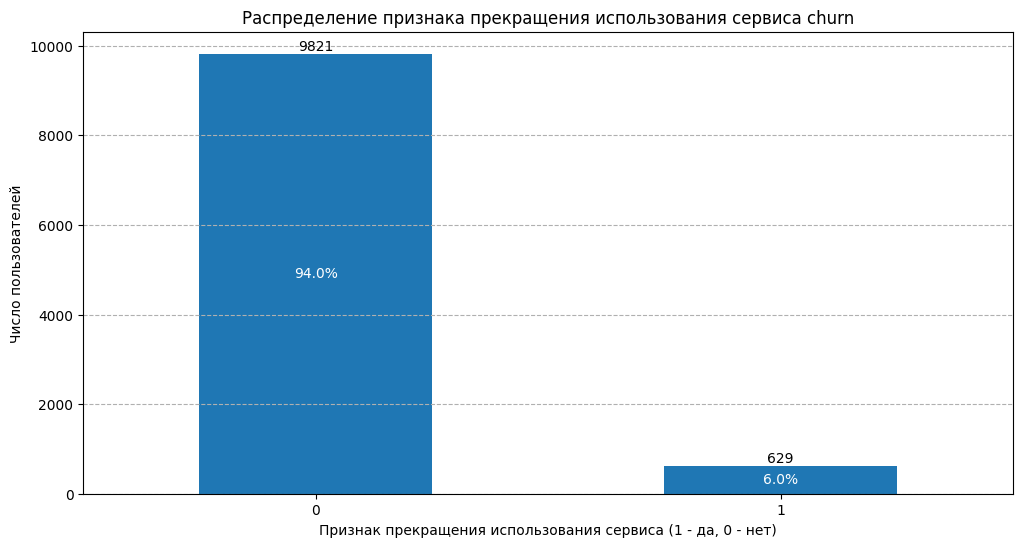

In [34]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
ax = df_init['churn'].value_counts().plot(
                kind='bar'
                , xlabel='Признак прекращения использования сервиса (1 - да, 0 - нет)'
                , ylabel='Число пользователей'
                , rot=0
                , legend=False
                , title='Распределение признака прекращения использования сервиса churn'
)
# Добавляем сетку графика
plt.grid(axis='y', linestyle='--')

# Добавление меток на столбики
for i, v in enumerate(df_init['churn'].value_counts()):
    ax.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=10)

total = df_init['churn'].value_counts().sum()
# Добавляем метки процентов
for i, v in enumerate(df_init['churn'].value_counts(normalize=True)):
    ax.text(i, v * total / 2, f'{(v) * 100:.1f}%', ha='center', va='center', fontsize=10, color='white')

# Выводим график
plt.show()

### Комментарий



## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.